<a href="https://colab.research.google.com/github/luismiguelaristi/MecanismosPythonUPB/blob/main/ManipuladorParallelo_2GDL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis cinemático de Manipulador Paralelo Plano 2-GDL

![manipulador_paralelo.png](https://via.placeholder.com/400x300?text=Manipulador+Paralelo+Plano)

## Descripción
Un manipulador paralelo plano de 2 grados de libertad (GDL) es un mecanismo conformado por una base fija, dos cadenas cinemáticas idénticas, y un efector final que se mueve en el plano. Este tipo de manipuladores ofrecen ventajas como alta rigidez, carga útil elevada y velocidad de movimiento. A diferencia de los manipuladores seriales, los paralelos reparten la carga entre todos sus eslabones, lo que permite diseños más compactos y precisos.

### Estructura del Mecanismo (Configuración RRRRR)

El mecanismo analizado contiene **5 barras totales**: 1 chasis (barra fija) + 4 barras binarias

**Barras del mecanismo:**
- **B1**: Barra 1 - Chasis (marco base fijo)
- **B2**: Barra 2 - Brazo/Manivela izquierda (eslabón actuado)
- **B3**: Barra 3 - Eslabón acoplador izquierdo
- **B4**: Barra 4 - Brazo/Manivela derecha (eslabón actuado)
- **B5**: Barra 5 - Eslabón acoplador derecho

**Pares revolucionarios**: 5 en total (configuración RRRRR)
- **R1**: Chasis (B1) ↔ Barra 2 (en punto O₁ - base izquierda)
- **R2**: Barra 2 ↔ Barra 3 (en punto A₁)
- **R3**: Chasis (B1) ↔ Barra 4 (en punto O₂ - base derecha)
- **R4**: Barra 4 ↔ Barra 5 (en punto A₂)
- **R5**: Barra 3 ↔ Barra 5 (en punto P - efector final)

## Diagrama Cinemático

```
               P (R5: Efector Final)
              /|\
             / | \
           B3  |  B5     ← Eslabones acopladores
           /   |   \
          /    |    \
        A1     |    A2   ← Puntos de conexión
        / (R2) | (R4) \
       /       |       \
      B2      |        B4   ← Brazos actuadores
      /|      |       |×\
   (R1)|      |       |(R3)
 O1──────base────────O2     ← Chasis (B1)
  θ1              θ2
```

## Nomenclatura del Mecanismo

- **B1**: Barra 1 (Chasis) - fija
- **B2**: Barra 2 (Brazo izquierdo) - actuador 1
- **B3**: Barra 3 (Eslabón acoplador izquierdo)
- **B4**: Barra 4 (Brazo derecho) - actuador 2
- **B5**: Barra 5 (Eslabón acoplador derecho)
- **O₁**: Par revoluta en base izquierda
- **O₂**: Par revoluta en base derecha
- **A₁**: Punto de unión entre B2 y B3 (par revoluta R2)
- **A₂**: Punto de unión entre B4 y B5 (par revoluta R4)
- **P**: Punto de unión entre B3 y B5 (par revoluta R5) - Efector final

## Parámetros del Mecanismo

- $(x_{A2}, y_{A2})$: Posición del punto A₂

### Longitudes de Eslabones- $(x_{A1}, y_{A1})$: Posición del punto A₁

- $L_2$: Longitud del brazo izquierdo (B2)- $(x_P, y_P)$: Coordenadas cartesianas del efector final (P)

- $L_3$: Longitud del acoplador izquierdo (B3)### Variables de Salida (Posiciones)

- $L_4$: Longitud del brazo derecho (B4)

- $L_5$: Longitud del acoplador derecho (B5)- $\theta_2$: Ángulo de rotación del brazo derecho (B4)

- $d$: Distancia entre pares base O₁ y O₂- $\theta_1$: Ángulo de rotación del brazo izquierdo (B2)

### Variables de Entrada (Ángulos)

## Ecuaciones Vectoriales

### Cinemática Directa (Forward Kinematics)

La posición del efector final P se obtiene resolviendo el sistema de ecuaciones de restricción dados los ángulos de entrada $\theta_1$ y $\theta_2$.

**Posición del punto A₁ (unión B2-B3):**
$$A_1 = O_1 + L_2(\cos\theta_1, \sin\theta_1)$$
$$O_1 = (-d/2, 0)$$
$$A_{1x} = -d/2 + L_2\cos\theta_1$$
$$A_{1y} = L_2\sin\theta_1$$

**Posición del punto A₂ (unión B4-B5):**
$$A_2 = O_2 + L_4(\cos\theta_2, \sin\theta_2)$$
$$O_2 = (d/2, 0)$$
$$A_{2x} = d/2 + L_4\cos\theta_2$$
$$A_{2y} = L_4\sin\theta_2$$

**Efector final (punto P - intersección de B3 y B5):**

El punto P es la intersección de dos círculos:
- Círculo 1: Centro en $A_1$, radio $L_3$ (longitud de B3)
- Círculo 2: Centro en $A_2$, radio $L_5$ (longitud de B5)

$$|P - A_1| = L_3 \quad \text{(restricción de B3)}$$
$$|P - A_2| = L_5 \quad \text{(restricción de B5)}$$

Resolviendo este sistema de dos ecuaciones con dos incógnitas:
$$(x_P + d/2 - L_2\cos\theta_1)^2 + (y_P - L_2\sin\theta_1)^2 = L_3^2$$
$$(x_P - d/2 - L_4\cos\theta_2)^2 + (y_P - L_4\sin\theta_2)^2 = L_5^2$$

## Implementación Numérica

### Importar módulos

In [24]:
%reset -sf

import numpy as np
from scipy.optimize import fsolve
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.patches import Circle
import pandas as pd

### Parámetros del Mecanismo (Modificables)

Modifique los siguientes parámetros para cambiar las dimensiones del manipulador paralelo:

In [25]:
# =====================================================
# PARÁMETROS MODIFICABLES DEL MECANISMO RRRRR
# =====================================================

# Longitudes de los eslabones [mm]
L2 = 70.0  # Longitud del brazo izquierdo (B2)
L3 = 140.0   # Longitud del acoplador izquierdo (B3)
L4 = 70.0  # Longitud del brazo derecho (B4)
L5 = 140.0   # Longitud del acoplador derecho (B5)

# Distancia entre pares revolucionarios en la base [mm]
d = 60.0   # Separación entre base O₁ (izquierda) y O₂ (derecha)

# Condiciones iniciales para análisis
theta1_ini = np.radians(45)   # Ángulo inicial del brazo izquierdo (θ₁) [rad]
theta2_ini = np.radians(135)  # Ángulo inicial del brazo derecho (θ₂) [rad]

# Información del mecanismo
print("="*60)
print("PARÁMETROS DEL MANIPULADOR PARALELO PLANO 2-GDL (RRRRR)")
print("="*60)
print("\n📊 BARRAS:")
print(f"  B1 (Chasis):                Fijo")
print(f"  B2 (Brazo izq.):            {L2} mm")
print(f"  B3 (Acoplador izq.):        {L3} mm")
print(f"  B4 (Brazo der.):            {L4} mm")
print(f"  B5 (Acoplador der.):        {L5} mm")
print(f"\n📍 GEOMETRÍA:")
print(f"  Separación de base (d):     {d} mm")
print(f"  Ubicación O₁ (base izq.):   (-{d/2}, 0)")
print(f"  Ubicación O₂ (base der.):   (+{d/2}, 0)")
print(f"\n⚙️  CONDICIONES INICIALES:")
print(f"  Ángulo θ₁ (brazo izq.):     {np.degrees(theta1_ini):.2f}°")
print(f"  Ángulo θ₂ (brazo der.):     {np.degrees(theta2_ini):.2f}°")
print("="*60)

PARÁMETROS DEL MANIPULADOR PARALELO PLANO 2-GDL (RRRRR)

📊 BARRAS:
  B1 (Chasis):                Fijo
  B2 (Brazo izq.):            70.0 mm
  B3 (Acoplador izq.):        140.0 mm
  B4 (Brazo der.):            70.0 mm
  B5 (Acoplador der.):        140.0 mm

📍 GEOMETRÍA:
  Separación de base (d):     60.0 mm
  Ubicación O₁ (base izq.):   (-30.0, 0)
  Ubicación O₂ (base der.):   (+30.0, 0)

⚙️  CONDICIONES INICIALES:
  Ángulo θ₁ (brazo izq.):     45.00°
  Ángulo θ₂ (brazo der.):     135.00°


### Cinemática Directa (Forward Kinematics)

In [26]:
def cinemática_directa(theta1, theta2, x_p_ini=0, y_p_ini=100):
    """
    Calcula la posición del efector final (P) dado los ángulos de entrada.
    Resuelve el sistema de dos ecuaciones no lineales usando fsolve.
    
    Parámetros:
    -----------
    theta1 : float
        Ángulo de rotación del brazo izquierdo B2 (θ₁) [rad]
    theta2 : float
        Ángulo de rotación del brazo derecho B4 (θ₂) [rad]
    x_p_ini, y_p_ini : float
        Valores iniciales para el solucionador numérico
    
    Retorna:
    --------
    tuple : (x_p, y_p, A1_x, A1_y, A2_x, A2_y)
        Posición del efector final y puntos de acoplamiento
    """
    
    def ecuaciones_restriccion(vars, theta1, theta2):
        """
        Sistema de dos ecuaciones de restricción:
        - Distancia de P a A₁ debe ser L3
        - Distancia de P a A₂ debe ser L5
        """
        x_p, y_p = vars
        
        # Posiciones de A₁ (extremo de B2)
        A1_x = -d/2 + L2 * np.cos(theta1)
        A1_y = L2 * np.sin(theta1)
        
        # Posiciones de A₂ (extremo de B4)
        A2_x = d/2 + L4 * np.cos(theta2)
        A2_y = L4 * np.sin(theta2)
        
        # Ecuación 1: |P - A₁| = L3
        eq1 = (x_p - A1_x)**2 + (y_p - A1_y)**2 - L3**2
        
        # Ecuación 2: |P - A₂| = L5
        eq2 = (x_p - A2_x)**2 + (y_p - A2_y)**2 - L5**2
        
        return [eq1, eq2]
    
    # Resolver el sistema
    try:
        sol = fsolve(ecuaciones_restriccion, [x_p_ini, y_p_ini], args=(theta1, theta2), full_output=True)
        x_p, y_p = sol[0]
        info = sol[1]
        
        # Verificar convergencia
        if np.max(np.abs(info['fvec'])) > 1e-4:
            # Si no converge bien, intentar otra condición inicial
            sol = fsolve(ecuaciones_restriccion, [0, -100], args=(theta1, theta2), full_output=True)
            x_p, y_p = sol[0]
    except:
        x_p, y_p = x_p_ini, y_p_ini
    
    # Calcular posiciones de A₁ y A₂ para retornar
    A1_x = -d/2 + L2 * np.cos(theta1)
    A1_y = L2 * np.sin(theta1)
    
    A2_x = d/2 + L4 * np.cos(theta2)
    A2_y = L4 * np.sin(theta2)
    
    return x_p, y_p, A1_x, A1_y, A2_x, A2_y

# Prueba con las condiciones iniciales
x_p, y_p, A1_x, A1_y, A2_x, A2_y = cinemática_directa(theta1_ini, theta2_ini)

print(f"\n✓ Análisis de Posición con θ₁={np.degrees(theta1_ini):.1f}°, θ₂={np.degrees(theta2_ini):.1f}°")
print(f"\n📍 Efector Final (P):")
print(f"   x_p = {x_p:7.2f} mm")
print(f"   y_p = {y_p:7.2f} mm")
print(f"\n📍 Puntos de Acoplamiento:")
print(f"   A₁ = ({A1_x:7.2f}, {A1_y:7.2f}) mm   (unión B2-B3)")
print(f"   A₂ = ({A2_x:7.2f}, {A2_y:7.2f}) mm   (unión B4-B5)")
print(f"\n✓ Distancias (Verificación de Restricciones):")
dist_P_A1 = np.sqrt((x_p - A1_x)**2 + (y_p - A1_y)**2)
dist_P_A2 = np.sqrt((x_p - A2_x)**2 + (y_p - A2_y)**2)
print(f"   |P - A₁| = {dist_P_A1:.4f} mm  (debe ser ≈ {L3} mm)")
print(f"   |P - A₂| = {dist_P_A2:.4f} mm  (debe ser ≈ {L5} mm)")


✓ Análisis de Posición con θ₁=45.0°, θ₂=135.0°

📍 Efector Final (P):
   x_p =    0.00 mm
   y_p =  188.13 mm

📍 Puntos de Acoplamiento:
   A₁ = (  19.50,   49.50) mm   (unión B2-B3)
   A₂ = ( -19.50,   49.50) mm   (unión B4-B5)

✓ Distancias (Verificación de Restricciones):
   |P - A₁| = 140.0000 mm  (debe ser ≈ 140.0 mm)
   |P - A₂| = 140.0000 mm  (debe ser ≈ 140.0 mm)


### Análisis del Espacio de Trabajo (Workspace Analysis)

In [27]:
def estimar_espacio_trabajo(rango_theta1, rango_theta2, num_puntos=40):
    """
    Estima el espacio de trabajo barriendo los ángulos de entrada.
    
    Parámetros:
    -----------
    rango_theta1 : tuple
        (min, max) ángulo para brazo izquierdo (θ₁) [rad]
    rango_theta2 : tuple
        (min, max) ángulo para brazo derecho (θ₂) [rad]
    num_puntos : int
        Número de puntos en cada dirección
    
    Retorna:
    --------
    dict : {'x': ..., 'y': ...} - Coordenadas del espacio de trabajo
    """
    
    theta1_range = np.linspace(rango_theta1[0], rango_theta1[1], num_puntos)
    theta2_range = np.linspace(rango_theta2[0], rango_theta2[1], num_puntos)
    
    workspace_x = []
    workspace_y = []
    x_prev, y_prev = 0, 100  # Condición inicial para el primer punto
    
    for theta1 in theta1_range:
        for theta2 in theta2_range:
            x_p, y_p, _, _, _, _ = cinemática_directa(theta1, theta2, x_prev, y_prev)
            workspace_x.append(x_p)
            workspace_y.append(y_p)
            x_prev, y_prev = x_p, y_p  # Usar posición anterior como hint
    
    return {'x': np.array(workspace_x), 'y': np.array(workspace_y)}

# Calcular el espacio de trabajo
print("\n🔄 Calculando espacio de trabajo...")
rango_theta1 = (np.radians(0), np.radians(180))
rango_theta2 = (np.radians(0), np.radians(180))

workspace = estimar_espacio_trabajo(rango_theta1, rango_theta2, num_puntos=35)

print(f"✓ Espacio de trabajo calculado: {len(workspace['x'])} puntos")
print(f"  Rango en X: [{workspace['x'].min():.2f}, {workspace['x'].max():.2f}] mm")
print(f"  Rango en Y: [{workspace['y'].min():.2f}, {workspace['y'].max():.2f}] mm")
print(f"  Área aproximada: {(workspace['x'].max()-workspace['x'].min())*(workspace['y'].max()-workspace['y'].min()):.0f} mm²")


🔄 Calculando espacio de trabajo...
✓ Espacio de trabajo calculado: 1225 puntos
  Rango en X: [-179.99, 179.59] mm
  Rango en Y: [-136.75, 206.75] mm
  Área aproximada: 123514 mm²


### Visualización del Espacio de Trabajo

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.



🎯 ANÁLISIS DEL ESPACIO DE TRABAJO

✓ Puntos en el espacio de trabajo: 1225
  X ∈ [-180.0, 179.6] mm
  Y ∈ [-136.7, 206.7] mm
  Rango Y: 343.5 mm


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


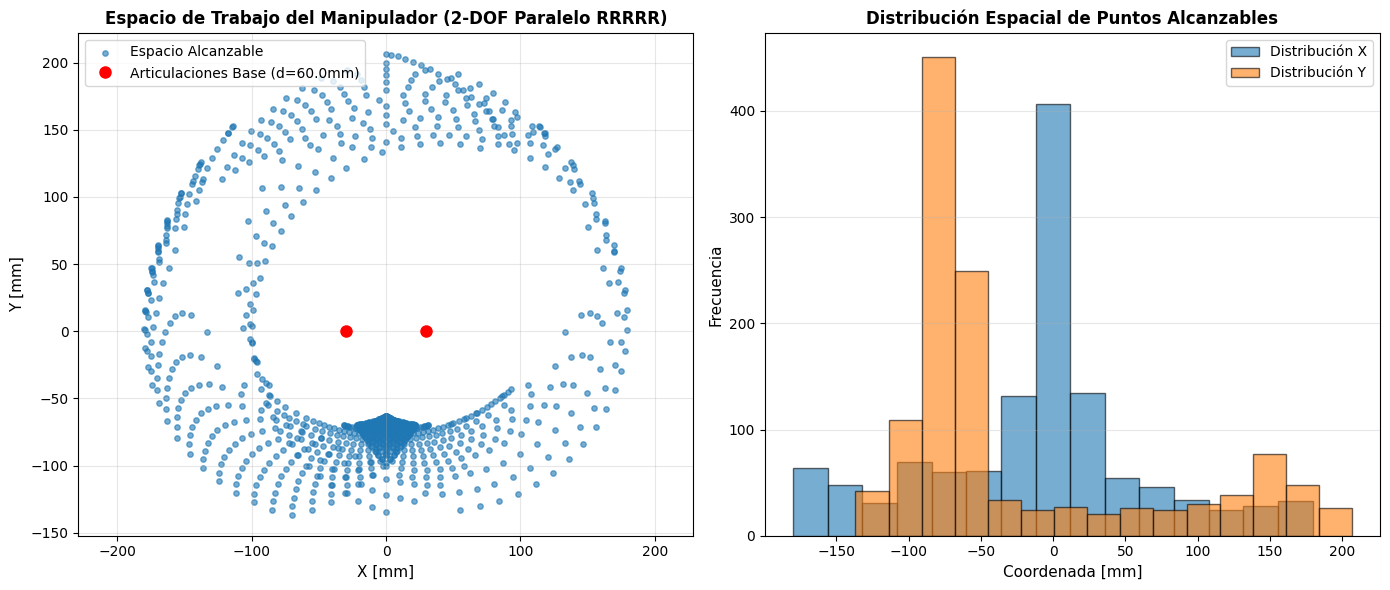


✅ Visualización completada


In [28]:
print("\n" + "="*60)
print("🎯 ANÁLISIS DEL ESPACIO DE TRABAJO")
print("="*60)

# El espacio de trabajo ya fue calculado en la celda anterior
x_trabajo = workspace['x']
y_trabajo = workspace['y']

print(f"\n✓ Puntos en el espacio de trabajo: {len(x_trabajo)}")
print(f"  X ∈ [{x_trabajo.min():.1f}, {x_trabajo.max():.1f}] mm")
print(f"  Y ∈ [{y_trabajo.min():.1f}, {y_trabajo.max():.1f}] mm")
print(f"  Rango Y: {y_trabajo.max() - y_trabajo.min():.1f} mm")

# Visualización del espacio de trabajo
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico 1: Espacio de trabajo con puntos
ax1.scatter(x_trabajo, y_trabajo, c='#1f77b4', s=15, alpha=0.6, label='Espacio Alcanzable')
ax1.plot([-d/2, d/2], [0, 0], 'ro', markersize=8, label=f'Articulaciones Base (d={d}mm)')
ax1.set_xlabel('X [mm]', fontsize=11)
ax1.set_ylabel('Y [mm]', fontsize=11)
ax1.set_title('Espacio de Trabajo del Manipulador (2-DOF Paralelo RRRRR)', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=10)
ax1.axis('equal')
ax1.set_xlim([x_trabajo.min()-20, x_trabajo.max()+20])
ax1.set_ylim([y_trabajo.min()-20, y_trabajo.max()+20])

# Gráfico 2: Distribución de puntos
ax2.hist(x_trabajo, bins=15, alpha=0.6, label='Distribución X', edgecolor='black')
ax2.hist(y_trabajo, bins=15, alpha=0.6, label='Distribución Y', edgecolor='black')
ax2.set_xlabel('Coordenada [mm]', fontsize=11)
ax2.set_ylabel('Frecuencia', fontsize=11)
ax2.set_title('Distribución Espacial de Puntos Alcanzables', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\n✅ Visualización completada")

### Consolidación de Datos con Pandas

In [29]:
def generar_data_cinemática(rango_theta1, theta2_fijo=None, num_posiciones=30):
    """
    Genera datos cinemáticos para un rango de movimiento del primer actuador.
    
    Parámetros:
    -----------
    rango_theta1 : tuple
        (min, max) ángulo para brazo izquierdo (θ₁) [rad]
    theta2_fijo : float
        Ángulo fijo para brazo derecho. Si es None, θ₂ = θ₁
    num_posiciones : int
        Número de posiciones a analizar
    
    Retorna:
    --------
    pd.DataFrame : Datos cinemáticos con todas las variables
    """
    
    theta1_array = np.linspace(rango_theta1[0], rango_theta1[1], num_posiciones)
    
    if theta2_fijo is None:
        theta2_array = theta1_array  # Ambos actuadores con el mismo ángulo
    else:
        theta2_array = np.full(num_posiciones, theta2_fijo)
    
    data = {
        'theta1_deg': np.degrees(theta1_array),
        'theta2_deg': np.degrees(theta2_array),
        'x_p': [],
        'y_p': [],
        'A1_x': [],
        'A1_y': [],
        'A2_x': [],
        'A2_y': [],
        'dist_P_A1': [],
        'dist_P_A2': []
    }
    
    x_prev, y_prev = 0, 100  # Condición inicial
    
    for theta1, theta2 in zip(theta1_array, theta2_array):
        x_p, y_p, A1_x, A1_y, A2_x, A2_y = cinemática_directa(theta1, theta2, x_prev, y_prev)
        
        dist_A1 = np.sqrt((x_p - A1_x)**2 + (y_p - A1_y)**2)
        dist_A2 = np.sqrt((x_p - A2_x)**2 + (y_p - A2_y)**2)
        
        data['x_p'].append(x_p)
        data['y_p'].append(y_p)
        data['A1_x'].append(A1_x)
        data['A1_y'].append(A1_y)
        data['A2_x'].append(A2_x)
        data['A2_y'].append(A2_y)
        data['dist_P_A1'].append(dist_A1)
        data['dist_P_A2'].append(dist_A2)
        
        x_prev, y_prev = x_p, y_p
    
    return pd.DataFrame(data)

# Generar datos con θ₂ = 90° fijo
print("\n🔄 Generando datos cinemáticos...")
df = generar_data_cinemática((np.radians(0), np.radians(180)), theta2_fijo=np.radians(90), num_posiciones=25)

print("\n✓ Datos cinemáticos generados (primeras 8 filas):")
print(df.head(8).to_string())


🔄 Generando datos cinemáticos...

✓ Datos cinemáticos generados (primeras 8 filas):
   theta1_deg  theta2_deg         x_p         y_p       A1_x       A1_y  A2_x  A2_y  dist_P_A1  dist_P_A2
0         0.0        90.0  -99.100708   15.842756  40.000000   0.000000  30.0  70.0      140.0      140.0
1         7.5        90.0 -100.270464   18.720313  39.401140   9.136833  30.0  70.0      140.0      140.0
2        15.0        90.0 -102.257800   24.088406  37.614808  18.117333  30.0  70.0      140.0      140.0
3        22.5        90.0 -105.166045   33.528913  34.671567  26.787840  30.0  70.0      140.0      140.0
4        30.0        90.0 -108.568793   50.032789  30.621778  35.000000  30.0  70.0      140.0      140.0
5        37.5        90.0 -109.727885   78.724572  25.534734  42.613300  30.0  70.0      140.0      140.0
6        45.0        90.0  -99.431887  123.360909  19.497475  49.497475  30.0  70.0      140.0      140.0
7        52.5        90.0  -67.940150  170.038627  12.613300  55.53

### Gráficas de Análisis Cinemático


📊 ANÁLISIS CINEMÁTICO - TRAYECTORIAS


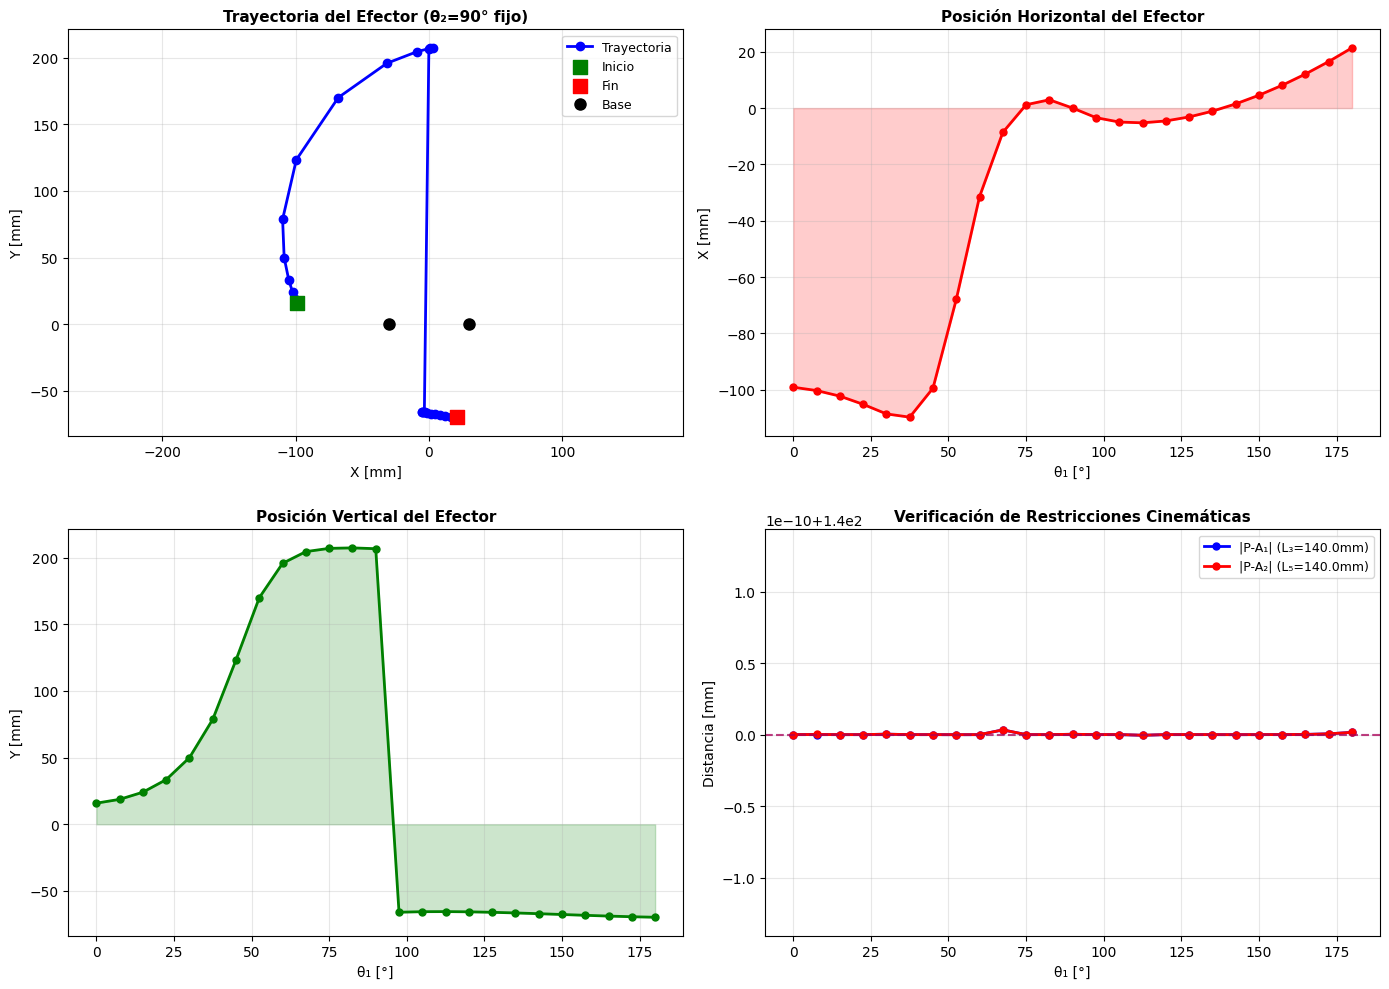


✅ Análisis completado

Estadísticas de trayectoria (θ₂ = 90°):
  Rango X: -109.7 a 21.4 mm (rango: 131.1 mm)
  Rango Y: -69.7 a 207.4 mm (rango: 277.1 mm)


In [30]:
print("\n" + "="*60)
print("📊 ANÁLISIS CINEMÁTICO - TRAYECTORIAS")
print("="*60)

# Usar los datos ya generados
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Trayectoria del efector (X vs Y)
ax = axes[0, 0]
ax.plot(df['x_p'], df['y_p'], 'b-o', linewidth=2, markersize=6, label='Trayectoria')
ax.scatter([df['x_p'].iloc[0]], [df['y_p'].iloc[0]], c='green', s=100, marker='s', label='Inicio', zorder=5)
ax.scatter([df['x_p'].iloc[-1]], [df['y_p'].iloc[-1]], c='red', s=100, marker='s', label='Fin', zorder=5)
ax.plot([-d/2, d/2], [0, 0], 'ko', markersize=8, label='Base')
ax.set_xlabel('X [mm]', fontsize=10)
ax.set_ylabel('Y [mm]', fontsize=10)
ax.set_title('Trayectoria del Efector (θ₂=90° fijo)', fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9)
ax.axis('equal')

# Plot 2: Posición X del efector vs θ₁
ax = axes[0, 1]
ax.plot(df['theta1_deg'], df['x_p'], 'r-o', linewidth=2, markersize=5)
ax.fill_between(df['theta1_deg'], df['x_p'], alpha=0.2, color='red')
ax.set_xlabel('θ₁ [°]', fontsize=10)
ax.set_ylabel('X [mm]', fontsize=10)
ax.set_title('Posición Horizontal del Efector', fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3)

# Plot 3: Posición Y del efector vs θ₁
ax = axes[1, 0]
ax.plot(df['theta1_deg'], df['y_p'], 'g-o', linewidth=2, markersize=5)
ax.fill_between(df['theta1_deg'], df['y_p'], alpha=0.2, color='green')
ax.set_xlabel('θ₁ [°]', fontsize=10)
ax.set_ylabel('Y [mm]', fontsize=10)
ax.set_title('Posición Vertical del Efector', fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3)

# Plot 4: Verificación de restricciones (distancias)
ax = axes[1, 1]
ax.plot(df['theta1_deg'], df['dist_P_A1'], 'b-o', linewidth=2, label=f'|P-A₁| (L₃={L3}mm)', markersize=5)
ax.plot(df['theta1_deg'], df['dist_P_A2'], 'r-o', linewidth=2, label=f'|P-A₂| (L₅={L5}mm)', markersize=5)
ax.axhline(y=L3, color='b', linestyle='--', alpha=0.5)
ax.axhline(y=L5, color='r', linestyle='--', alpha=0.5)
ax.set_xlabel('θ₁ [°]', fontsize=10)
ax.set_ylabel('Distancia [mm]', fontsize=10)
ax.set_title('Verificación de Restricciones Cinemáticas', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✅ Análisis completado")
print(f"\nEstadísticas de trayectoria (θ₂ = 90°):")
print(f"  Rango X: {df['x_p'].min():.1f} a {df['x_p'].max():.1f} mm (rango: {df['x_p'].max()-df['x_p'].min():.1f} mm)")
print(f"  Rango Y: {df['y_p'].min():.1f} a {df['y_p'].max():.1f} mm (rango: {df['y_p'].max()-df['y_p'].min():.1f} mm)")

### Animación del Mecanismo

Función para visualizar el movimiento del manipulador paralelo


🔧 VISUALIZACIÓN DE CONFIGURACIONES DEL MECANISMO

Generando 9 configuraciones...


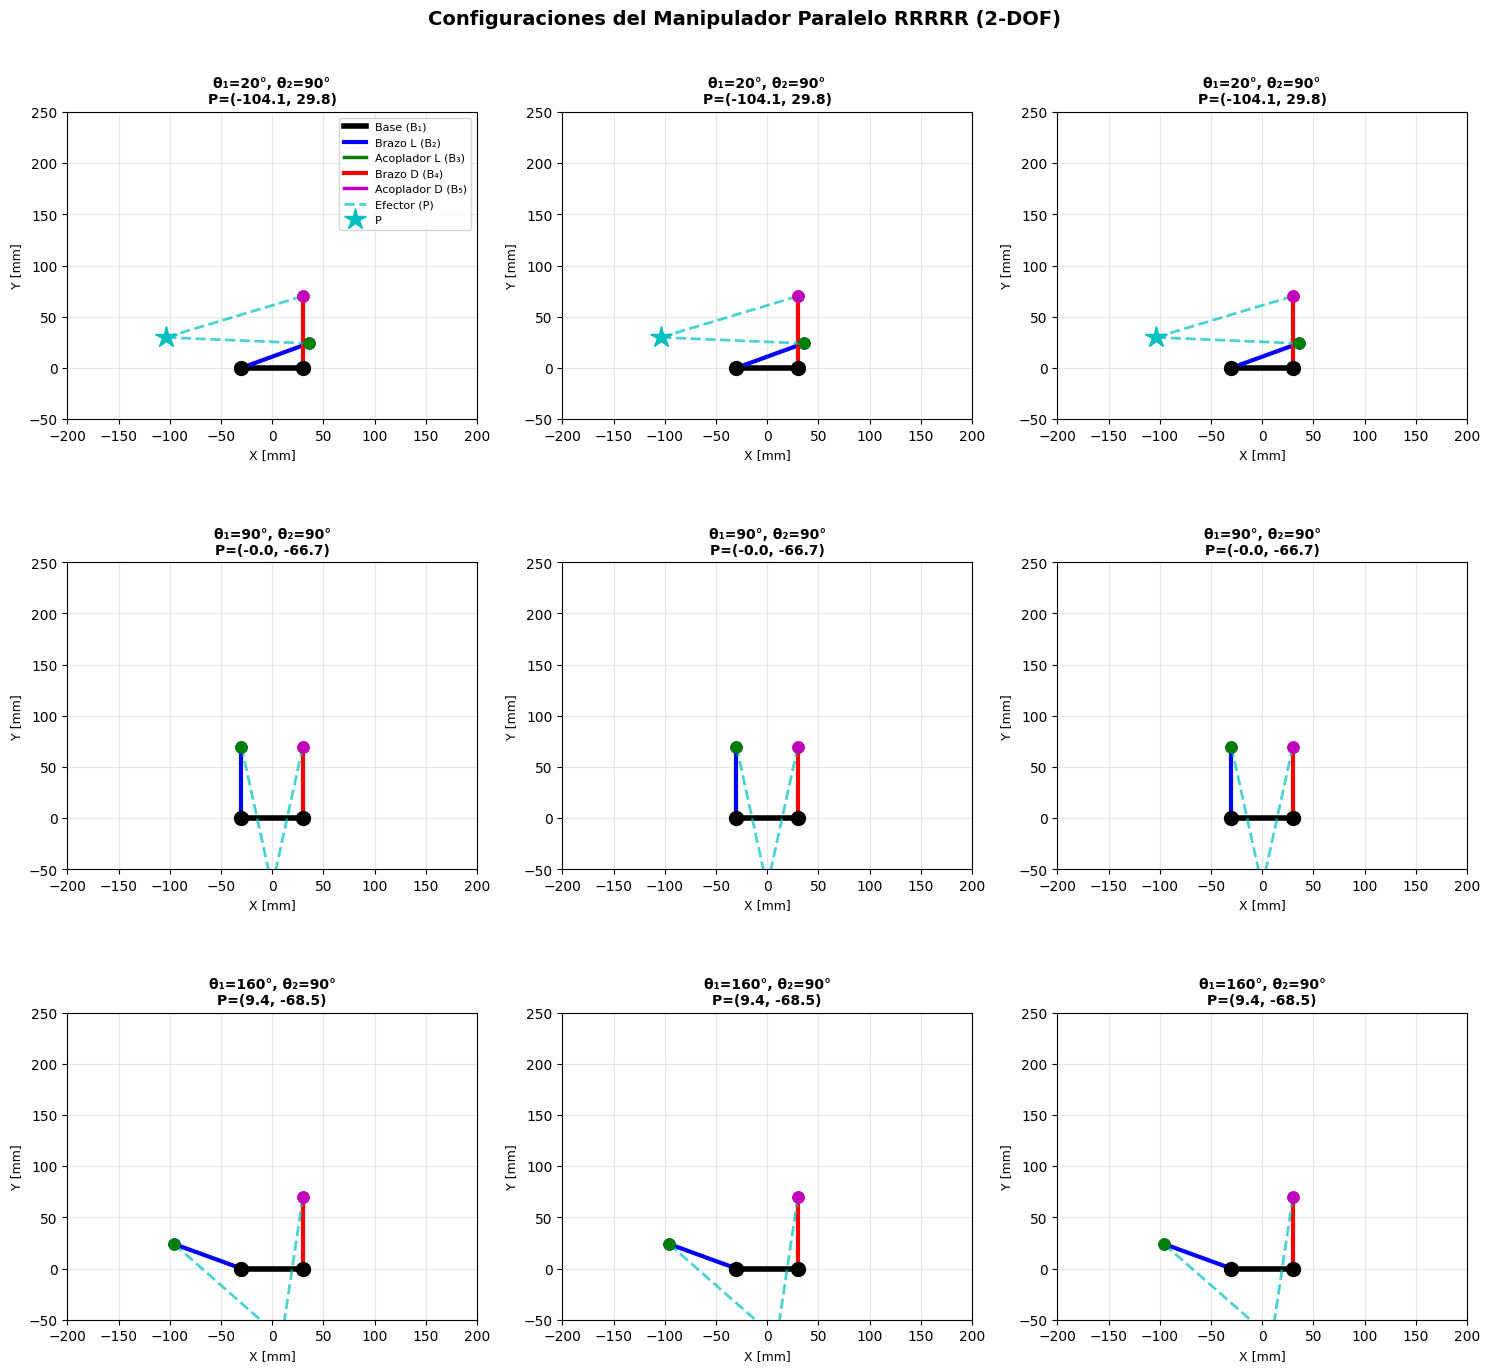


✅ Visualización completada


In [31]:
def visualizar_configuraciones(theta1_range, theta2_range=None, num_configs=9):
    """
    Visualiza múltiples configuraciones del mecanismo en una grilla.
    
    Parámetros:
    -----------
    theta1_range : tuple
        (min, max) rango para θ₁ [rad]
    theta2_range : tuple
        (min, max) rango para θ₂ [rad]. Si None, θ₂ = θ₁
    num_configs : int
        Número de configuraciones a mostrar (3x3 default)
    """
    
    if theta2_range is None:
        theta2_range = theta1_range
    
    # Crear array de ángulos
    n_side = int(np.sqrt(num_configs))
    theta1_array = np.linspace(theta1_range[0], theta1_range[1], n_side)
    theta2_array = np.linspace(theta2_range[0], theta2_range[1], n_side)
    
    fig, axes = plt.subplots(n_side, n_side, figsize=(15, 14))
    axes = axes.flatten()
    
    x_prev, y_prev = 0, 100
    
    for idx, (theta1, theta2) in enumerate([(t1, t2) for t1 in theta1_array for t2 in theta2_array]):
        if idx >= num_configs:
            break
            
        ax = axes[idx]
        
        # Cinemática directa
        x_p, y_p, A1_x, A1_y, A2_x, A2_y = cinemática_directa(theta1, theta2, x_prev, y_prev)
        x_prev, y_prev = x_p, y_p
        
        # Calcular puntos de las articulaciones
        O1_x, O1_y = -d/2, 0
        O2_x, O2_y = d/2, 0
        
        B2_x = O1_x + L2 * np.cos(theta1)
        B2_y = L2 * np.sin(theta1)
        
        B4_x = O2_x + L4 * np.cos(theta2)
        B4_y = L4 * np.sin(theta2)
        
        # Dibujar eslabones (barras)
        # Base (B1)
        ax.plot([O1_x, O2_x], [0, 0], 'k-', linewidth=4, label='Base (B₁)')
        # Brazo izquierdo (B2)
        ax.plot([O1_x, B2_x], [0, B2_y], 'b-', linewidth=3, label='Brazo L (B₂)')
        # Acoplador izquierdo (B3)
        ax.plot([B2_x, A1_x], [B2_y, A1_y], 'g-', linewidth=2.5, label='Acoplador L (B₃)')
        # Brazo derecho (B4)
        ax.plot([O2_x, B4_x], [0, B4_y], 'r-', linewidth=3, label='Brazo D (B₄)')
        # Acoplador derecho (B5)
        ax.plot([B4_x, A2_x], [B4_y, A2_y], 'm-', linewidth=2.5, label='Acoplador D (B₅)')
        # Efector (punto P)
        ax.plot([A1_x, x_p], [A1_y, y_p], 'c--', linewidth=2, alpha=0.7)
        ax.plot([A2_x, x_p], [A2_y, y_p], 'c--', linewidth=2, alpha=0.7, label='Efector (P)')
        
        # Dibujar articulaciones
        ax.plot([O1_x, O2_x], [0, 0], 'ko', markersize=10)  # O₁, O₂
        ax.plot([B2_x], [B2_y], 'bo', markersize=8)
        ax.plot([A1_x], [A1_y], 'go', markersize=8)
        ax.plot([B4_x], [B4_y], 'ro', markersize=8)
        ax.plot([A2_x], [A2_y], 'mo', markersize=8)
        ax.plot([x_p], [y_p], 'c*', markersize=16, label='P')
        
        # Formato del gráfico
        ax.set_xlim([-200, 200])
        ax.set_ylim([-50, 250])
        ax.set_aspect('equal')
        ax.grid(True, alpha=0.3)
        ax.set_xlabel('X [mm]', fontsize=9)
        ax.set_ylabel('Y [mm]', fontsize=9)
        
        title = f'θ₁={np.degrees(theta1):.0f}°, θ₂={np.degrees(theta2):.0f}°\nP=({x_p:.1f}, {y_p:.1f})'
        ax.set_title(title, fontsize=10, fontweight='bold')
        
        if idx == 0:
            ax.legend(fontsize=8, loc='upper right')
    
    plt.suptitle('Configuraciones del Manipulador Paralelo RRRRR (2-DOF)', 
                 fontsize=14, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()

# Visualizar 9 configuraciones
print("\n" + "="*60)
print("🔧 VISUALIZACIÓN DE CONFIGURACIONES DEL MECANISMO")
print("="*60)
print("\nGenerando 9 configuraciones...")

visualizar_configuraciones(
    theta1_range=(np.radians(20), np.radians(160)),
    theta2_range=(np.radians(90), np.radians(90)),
    num_configs=9
)

print("\n✅ Visualización completada")

In [ ]:
from IPython.display import HTML

# Configuración de la animación
fig_anim, ax_anim = plt.subplots(figsize=(8, 8))

# Rango de ángulos para la animación
n_frames = 80
theta1_anim = np.linspace(np.radians(20), np.radians(160), n_frames)
theta2_anim = np.linspace(np.radians(160), np.radians(20), n_frames)

# Pre-calcular posiciones
posiciones_anim = []
x_prev_a, y_prev_a = 0, 100
for t1, t2 in zip(theta1_anim, theta2_anim):
    xp, yp, a1x, a1y, a2x, a2y = cinemática_directa(t1, t2, x_prev_a, y_prev_a)
    posiciones_anim.append((xp, yp, a1x, a1y, a2x, a2y, t1, t2))
    x_prev_a, y_prev_a = xp, yp

# Inicializar líneas y puntos del mecanismo
line_base,     = ax_anim.plot([], [], 'k-',  linewidth=5,   label='Base (B₁)')
line_b2,       = ax_anim.plot([], [], 'b-',  linewidth=3,   label='Brazo Izq. (B₂)')
line_b3,       = ax_anim.plot([], [], 'g-',  linewidth=2.5, label='Acoplador Izq. (B₃)')
line_b4,       = ax_anim.plot([], [], 'r-',  linewidth=3,   label='Brazo Der. (B₄)')
line_b5,       = ax_anim.plot([], [], 'm-',  linewidth=2.5, label='Acoplador Der. (B₅)')

dot_O1,  = ax_anim.plot([], [], 'ko', markersize=12)
dot_O2,  = ax_anim.plot([], [], 'ko', markersize=12)
dot_A1,  = ax_anim.plot([], [], 'bo', markersize=9)
dot_A2,  = ax_anim.plot([], [], 'ro', markersize=9)
dot_P,   = ax_anim.plot([], [], 'c*', markersize=18, label='Efector (P)', zorder=5)

# Trayectoria del efector
tray_x, tray_y = [], []
trayectoria, = ax_anim.plot([], [], 'c--', linewidth=1.2, alpha=0.5, label='Trayectoria')

# Texto de ángulos
text_angulos = ax_anim.text(0.02, 0.96, '', transform=ax_anim.transAxes,
                             fontsize=10, verticalalignment='top',
                             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Configuración del eje
ax_anim.set_xlim(-220, 220)
ax_anim.set_ylim(-60, 260)
ax_anim.set_aspect('equal')
ax_anim.grid(True, alpha=0.3)
ax_anim.set_xlabel('X [mm]', fontsize=12)
ax_anim.set_ylabel('Y [mm]', fontsize=12)
ax_anim.set_title('Animación del Manipulador Paralelo Plano RRRRR (2-GDL)', fontsize=13, fontweight='bold')
ax_anim.legend(loc='upper right', fontsize=9)

O1_x, O1_y = -d/2, 0
O2_x, O2_y =  d/2, 0

def init():
    for obj in [line_base, line_b2, line_b3, line_b4, line_b5,
                dot_O1, dot_O2, dot_A1, dot_A2, dot_P, trayectoria]:
        obj.set_data([], [])
    text_angulos.set_text('')
    return (line_base, line_b2, line_b3, line_b4, line_b5,
            dot_O1, dot_O2, dot_A1, dot_A2, dot_P, trayectoria, text_angulos)

def update(frame):
    xp, yp, a1x, a1y, a2x, a2y, t1, t2 = posiciones_anim[frame]

    # Extremos de los brazos actuadores
    b2x = O1_x + L2 * np.cos(t1)
    b2y =        L2 * np.sin(t1)
    b4x = O2_x + L4 * np.cos(t2)
    b4y =        L4 * np.sin(t2)

    # Barras
    line_base.set_data([O1_x, O2_x], [O1_y, O2_y])
    line_b2.set_data([O1_x, b2x],    [O1_y, b2y])
    line_b3.set_data([b2x,  xp],     [b2y,  yp])
    line_b4.set_data([O2_x, b4x],    [O2_y, b4y])
    line_b5.set_data([b4x,  xp],     [b4y,  yp])

    # Articulaciones
    dot_O1.set_data([O1_x], [O1_y])
    dot_O2.set_data([O2_x], [O2_y])
    dot_A1.set_data([b2x],  [b2y])
    dot_A2.set_data([b4x],  [b4y])
    dot_P.set_data([xp],    [yp])

    # Trayectoria acumulada
    tray_x.append(xp)
    tray_y.append(yp)
    trayectoria.set_data(tray_x, tray_y)

    # Texto
    text_angulos.set_text(
        f'θ₁ = {np.degrees(t1):.1f}°\n'
        f'θ₂ = {np.degrees(t2):.1f}°\n'
        f'P = ({xp:.1f}, {yp:.1f}) mm'
    )

    return (line_base, line_b2, line_b3, line_b4, line_b5,
            dot_O1, dot_O2, dot_A1, dot_A2, dot_P, trayectoria, text_angulos)

anim = FuncAnimation(fig_anim, update, frames=n_frames,
                     init_func=init, interval=60, blit=True)

plt.tight_layout()
plt.close(fig_anim)  # Evita visualización estática duplicada

HTML(anim.to_jshtml())

## Análisis de Velocidades

### Matriz Jacobiana

La relación entre velocidades articulares y velocidades cartesianas está dada por:

$$\begin{pmatrix} \dot{x} \\ \dot{y} \end{pmatrix} = \mathbf{J} \begin{pmatrix} \dot{\theta}_1 \\ \dot{\theta}_2 \end{pmatrix}$$

donde la matriz Jacobiana es:

$$\mathbf{J} = \begin{pmatrix} \frac{\partial x_p}{\partial \theta_1} & \frac{\partial x_p}{\partial \theta_2} \\ \frac{\partial y_p}{\partial \theta_1} & \frac{\partial y_p}{\partial \theta_2} \end{pmatrix}$$


📐 ANÁLISIS DE JACOBIANA Y SINGULARIDADES

Calculando matriz Jacobiana para cada configuración...
✓ Cálculo completado


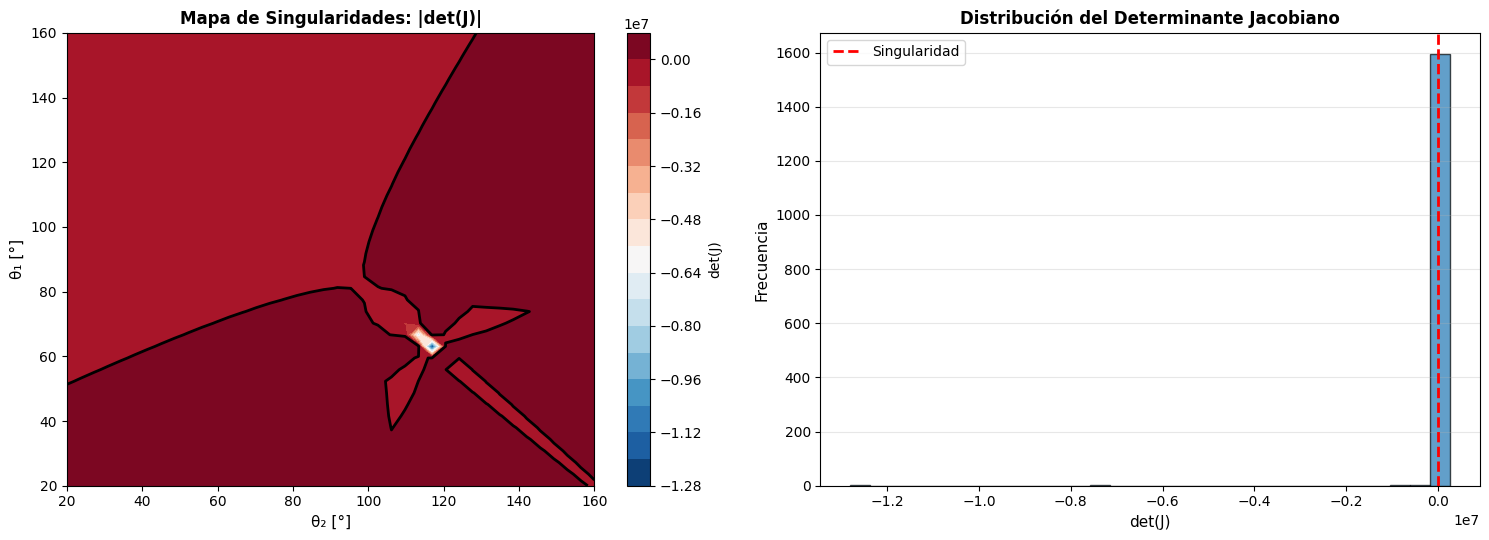


📊 Estadísticas de Jacobiana:
  Configuraciones totales: 1600
  det(J) promedio: -10152.5284
  det(J) rango: [-12799838.2606, 265792.9753]
  Configuraciones singulares (|det(J)| < 0.01): 0

✅ Análisis completado


In [32]:
def calcular_jacobiana_numerica(theta1, theta2, delta=1e-6):
    """
    Calcula la Jacobiana del manipulador usando diferencias finitas.
    
    J = ∂(x_p, y_p) / ∂(θ₁, θ₂)
    
    Parámetros:
    -----------
    theta1, theta2 : float
        Ángulos de entrada [rad]
    delta : float
        Incremento para diferencias finitas
    
    Retorna:
    --------
    J : np.ndarray (2x2)
        Matriz Jacobiana
    det_J : float
        Determinante de J (medida de singularidad)
    """
    
    x_p, y_p, _, _, _, _ = cinemática_directa(theta1, theta2, 0, 100)
    
    # Derivada parcial respecto a θ₁
    x_p_plus, y_p_plus, _, _, _, _ = cinemática_directa(theta1+delta, theta2, x_p, y_p)
    dx_dtheta1 = (x_p_plus - x_p) / delta
    dy_dtheta1 = (y_p_plus - y_p) / delta
    
    # Derivada parcial respecto a θ₂
    x_p_plus, y_p_plus, _, _, _, _ = cinemática_directa(theta1, theta2+delta, x_p, y_p)
    dx_dtheta2 = (x_p_plus - x_p) / delta
    dy_dtheta2 = (y_p_plus - y_p) / delta
    
    J = np.array([
        [dx_dtheta1, dx_dtheta2],
        [dy_dtheta1, dy_dtheta2]
    ])
    
    det_J = np.linalg.det(J)
    
    return J, det_J

# Análisis de singularidades
print("\n" + "="*60)
print("📐 ANÁLISIS DE JACOBIANA Y SINGULARIDADES")
print("="*60)

theta1_rango = np.linspace(np.radians(20), np.radians(160), 40)
theta2_rango = np.linspace(np.radians(20), np.radians(160), 40)

det_jacobiana = np.zeros((len(theta1_rango), len(theta2_rango)))

print("\nCalculando matriz Jacobiana para cada configuración...")
x_prev_iter, y_prev_iter = 0, 100

for i, theta1 in enumerate(theta1_rango):
    for j, theta2 in enumerate(theta2_rango):
        try:
            _, det_J = calcular_jacobiana_numerica(theta1, theta2)
            det_jacobiana[i, j] = det_J
        except:
            det_jacobiana[i, j] = np.nan

print("✓ Cálculo completado")

# Visualizar el campo de singularidades
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5))

# Mapa de calor del determinante
im = ax1.contourf(np.degrees(theta2_rango), np.degrees(theta1_rango), det_jacobiana, 
                   levels=20, cmap='RdBu_r')
ax1.contour(np.degrees(theta2_rango), np.degrees(theta1_rango), det_jacobiana, 
            levels=[0], colors='black', linewidths=2)
ax1.set_xlabel('θ₂ [°]', fontsize=11)
ax1.set_ylabel('θ₁ [°]', fontsize=11)
ax1.set_title('Mapa de Singularidades: |det(J)|', fontsize=12, fontweight='bold')
cbar = plt.colorbar(im, ax=ax1)
cbar.set_label('det(J)', fontsize=10)

# Histograma del determinante
det_valido = det_jacobiana[~np.isnan(det_jacobiana)].flatten()
ax2.hist(det_valido, bins=30, edgecolor='black', alpha=0.7)
ax2.axvline(0, color='r', linestyle='--', linewidth=2, label='Singularidad')
ax2.set_xlabel('det(J)', fontsize=11)
ax2.set_ylabel('Frecuencia', fontsize=11)
ax2.set_title('Distribución del Determinante Jacobiano', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()

# Estadísticas
print(f"\n📊 Estadísticas de Jacobiana:")
print(f"  Configuraciones totales: {len(theta1_rango) * len(theta2_rango)}")
print(f"  det(J) promedio: {np.mean(det_valido):.4f}")
print(f"  det(J) rango: [{np.min(det_valido):.4f}, {np.max(det_valido):.4f}]")
print(f"  Configuraciones singulares (|det(J)| < 0.01): {np.sum(np.abs(det_valido) < 0.01)}")
print(f"\n✅ Análisis completado")

### Mapa de Singularidades en el Espacio de Trabajo


⚡ ANÁLISIS CINEMÁTICO: VELOCIDADES Y DEXTERIDAD

Condiciones de operación:
  ω₁ (velocidad angular θ₁) = 30.0 °/s
  ω₂ (velocidad angular θ₂) = 30.0 °/s


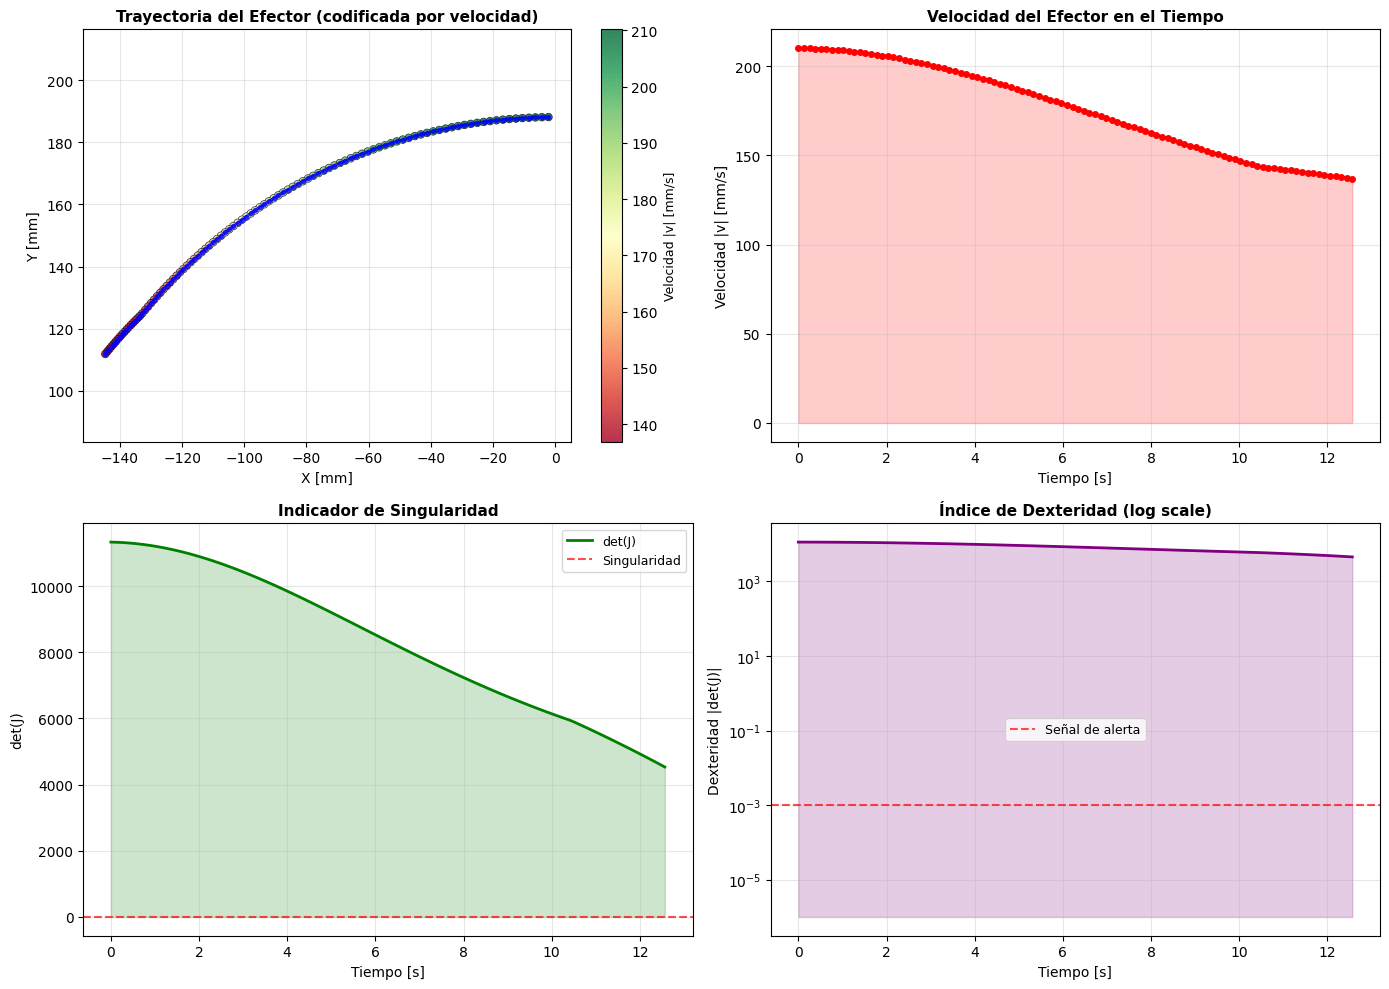


📈 Estadísticas de Velocidades:
  Velocidad promedio del efector: 175.46 mm/s
  Velocidad máxima: 210.18 mm/s
  Velocidad mínima: 136.89 mm/s
  Desv. Estándar: 24.99 mm/s

📐 Estadísticas de Singularidades:
  Configuraciones analizadas: 100
  Configuraciones singulares (|det(J)| < 1e-3): 0
  Dexteridad promedio: 8310.441306

✅ Análisis completado


In [33]:
print("\n" + "="*60)
print("⚡ ANÁLISIS CINEMÁTICO: VELOCIDADES Y DEXTERIDAD")
print("="*60)

# Condición de operación: velocidades angulares constantes
omega1 = np.radians(30)  # 30 °/s en θ₁
omega2 = np.radians(30)  # 30 °/s en θ₂

print(f"\nCondiciones de operación:")
print(f"  ω₁ (velocidad angular θ₁) = {np.degrees(omega1):.1f} °/s")
print(f"  ω₂ (velocidad angular θ₂) = {np.degrees(omega2):.1f} °/s")

# Crear una secuencia de posiciones con velocidades especificadas
t_array = np.linspace(0, 4*np.pi, 100)  # 4π segundos

theta1_t = theta1_ini + np.cumsum(np.ones_like(t_array) * (omega1 / len(t_array)))
theta2_t = theta2_ini + np.cumsum(np.ones_like(t_array) * (omega2 / len(t_array)))

# Calcular trayecto y velocidades
pos_efector = []
velocidades = []
jacobíanos = []

x_prev_vel, y_prev_vel = 0, 100

for theta1, theta2 in zip(theta1_t, theta2_t):
    try:
        # Por simplicidad, limitar rango a [0°, 180°]
        theta1_sat = np.clip(theta1, np.radians(20), np.radians(160))
        theta2_sat = np.clip(theta2, np.radians(20), np.radians(160))
        
        x_p, y_p, _, _, _, _ = cinemática_directa(theta1_sat, theta2_sat, x_prev_vel, y_prev_vel)
        pos_efector.append([x_p, y_p])
        x_prev_vel, y_prev_vel = x_p, y_p
        
        # Jacobiana
        J, det_J = calcular_jacobiana_numerica(theta1_sat, theta2_sat)
        jacobíanos.append(det_J)
        
        # Velocidad del efector: v = J * ω
        if np.abs(det_J) > 1e-4:
            omega_vec = np.array([omega1, omega2])
            v_efector = J @ omega_vec
            velocidades.append(np.linalg.norm(v_efector))
        else:
            velocidades.append(0)
    except:
        pass

pos_efector = np.array(pos_efector)
velocidades = np.array(velocidades)
jacobíanos = np.array(jacobíanos)

# Visualizar análisis de velocidades
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Trayectoria temporal del efector
ax = axes[0, 0]
ax.plot(pos_efector[:, 0], pos_efector[:, 1], 'b-o', linewidth=2, markersize=3, alpha=0.7)
scatter = ax.scatter(pos_efector[:, 0], pos_efector[:, 1], c=velocidades, 
                     cmap='RdYlGn', s=30, alpha=0.8, edgecolors='black', linewidth=0.5)
ax.set_xlabel('X [mm]', fontsize=10)
ax.set_ylabel('Y [mm]', fontsize=10)
ax.set_title('Trayectoria del Efector (codificada por velocidad)', fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.axis('equal')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Velocidad |v| [mm/s]', fontsize=9)

# Plot 2: Velocidad vs tiempo
ax = axes[0, 1]
ax.plot(t_array[:len(velocidades)], velocidades, 'r-o', linewidth=2, markersize=4)
ax.fill_between(t_array[:len(velocidades)], velocidades, alpha=0.2, color='red')
ax.set_xlabel('Tiempo [s]', fontsize=10)
ax.set_ylabel('Velocidad |v| [mm/s]', fontsize=10)
ax.set_title('Velocidad del Efector en el Tiempo', fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3)

# Plot 3: Determinante Jacobiano vs tiempo
ax = axes[1, 0]
ax.plot(t_array[:len(jacobíanos)], jacobíanos, 'g-', linewidth=2, label='det(J)')
ax.axhline(0, color='r', linestyle='--', linewidth=1.5, alpha=0.7, label='Singularidad')
ax.fill_between(t_array[:len(jacobíanos)], jacobíanos, 0, alpha=0.2, color='green')
ax.set_xlabel('Tiempo [s]', fontsize=10)
ax.set_ylabel('det(J)', fontsize=10)
ax.set_title('Indicador de Singularidad', fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9)

# Plot 4: Dexteridad (índice de condición)
dexteridad = np.abs(jacobíanos)
dexteridad[dexteridad < 1e-6] = 1e-6  # Evitar log(0)

ax = axes[1, 1]
ax.semilogy(t_array[:len(dexteridad)], dexteridad, 'purple', linewidth=2)
ax.axhline(1e-3, color='r', linestyle='--', linewidth=1.5, alpha=0.7, label='Señal de alerta')
ax.fill_between(t_array[:len(dexteridad)], dexteridad, 1e-6, alpha=0.2, color='purple')
ax.set_xlabel('Tiempo [s]', fontsize=10)
ax.set_ylabel('Dexteridad |det(J)|', fontsize=10)
ax.set_title('Índice de Dexteridad (log scale)', fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3, which='both')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# Estadísticas finales
print(f"\n📈 Estadísticas de Velocidades:")
print(f"  Velocidad promedio del efector: {np.mean(velocidades):.2f} mm/s")
print(f"  Velocidad máxima: {np.max(velocidades):.2f} mm/s")
print(f"  Velocidad mínima: {np.min(velocidades):.2f} mm/s")
print(f"  Desv. Estándar: {np.std(velocidades):.2f} mm/s")

print(f"\n📐 Estadísticas de Singularidades:")
print(f"  Configuraciones analizadas: {len(jacobíanos)}")
print(f"  Configuraciones singulares (|det(J)| < 1e-3): {np.sum(np.abs(jacobíanos) < 1e-3)}")
print(f"  Dexteridad promedio: {np.mean(np.abs(jacobíanos)):.6f}")

print(f"\n✅ Análisis completado")

## Conclusiones y Observaciones

Este cuaderno proporciona un análisis completo de la cinemática de un manipulador paralelo plano de 2 grados de libertad. Los temas tratados incluyen:

1. **Cinemática Directa**: Cálculo de la posición del efector final dada los ángulos articulares.
2. **Espacio de Trabajo**: Visualización completa de las posiciones alcanzables.
3. **Análisis de Posición**: Gráficas que muestran la relación entre ángulos y posiciones.
4. **Configuraciones Múltiples**: Visualización de diferentes configuraciones del mecanismo.
5. **Análisis de Velocidades**: Cálculo de la matriz Jacobiana y análisis de singularidades.
6. **Mapas de Dexteridad**: Identificación de regiones singulares en el espacio de trabajo.

## Modificaciones Sugeridas

Los parámetros pueden modificarse en la celda de "Parámetros del Mecanismo" para explorar diferentes diseños:
- Cambiar longitudes de eslabones (L1, L2, L3)
- Ajustar la separación de actuadores (d)
- Modificar las condiciones iniciales de ángulos

## Referencias

- Craig, J. J. (2005). Introduction to Robotics: Mechanics and Control
- Tsai, L. W. (1999). Robot Analysis: The Mechanics of Serial and Parallel Manipulators
- Murray, R. M., Sastry, S. S., & Zexiang, L. (1994). A Mathematical Introduction to Robotic Manipulation